In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [ ]:
df = pd.read_csv("financial_news_events.csv")

In [ ]:
df.head()

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
0,2025-05-21,Nikkei 225 index benefits from a weaker yen,Times of India,Commodity Price Shock,DAX,3.52,166.45,NaN,Technology,High,Goldman Sachs,https://timesofindia.indiatimes.com/business/m...
1,2025-05-18,Government subsidy program gives a lift to the...,Financial Times,Central Bank Meeting,Shanghai Composite,-3.39,57.61,NaN,Retail,Low,ExxonMobil,https://timesofindia.indiatimes.com/business/m...
2,2025-06-25,New housing data release shows a slowdown in m...,The Hindu Business Line,Consumer Confidence Report,Shanghai Composite,-0.05,403.22,Neutral,Retail,Medium,Boeing,https://www.moneycontrol.com/us-markets/sp-500
3,2025-07-21,Massive stock buyback program announced by a c...,The Economist,Commodity Price Shock,NSE Nifty,-2.29,100.11,Positive,Consumer Goods,Low,Samsung Electronics,https://www.cnbc.com/2025/09/automotive-indust...
4,2025-07-23,Government spending bill is expected to stimul...,The Motley Fool,Inflation Data Release,Nasdaq Composite,-3.97,438.22,Negative,Consumer Goods,Low,JP Morgan Chase,https://www.bloomberg.com/australia/asx-200-pe...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  3024 non-null   object 
 1   Headline              2876 non-null   object 
 2   Source                3024 non-null   object 
 3   Market_Event          3024 non-null   object 
 4   Market_Index          3024 non-null   object 
 5   Index_Change_Percent  2863 non-null   float64
 6   Trading_Volume        3024 non-null   float64
 7   Sentiment             2853 non-null   object 
 8   Sector                3024 non-null   object 
 9   Impact_Level          3024 non-null   object 
 10  Related_Company       3024 non-null   object 
 11  News_Url              2871 non-null   object 
dtypes: float64(2), object(10)
memory usage: 283.6+ KB


From this, we can see our features include: Date, Headline, Source, Market_Event, Market_Index, Index_Change_Percent, Trading_Volume, Sentiment, Sector, Impact_Level, Related_Company, News_Url. We

In [ ]:
df.describe()

,Index_Change_Percent,Trading_Volume
count,2863.000000,3024.000000
mean,-0.021753,249.037917
std,2.851991,145.497932
min,-4.990000,1.060000
25%,-2.450000,120.427500
50%,-0.100000,244.020000
75%,2.475000,377.000000
max,5.000000,499.830000


From this we can observe the distirbution of Indec_Change_Percentet is centered near zero. which indicates positive and negative movements. The range is also roughly between -5% to 5%, suggesting moderate market volatility as these are realistic daily index movements.
Trading volume has a standard deviation of 145.497, which indicates diverse market activity levels.

In [ ]:
df.isna().sum().sort_values()

Date                      0
Source                    0
Market_Event              0
Market_Index              0
Trading_Volume            0
Sector                    0
Impact_Level              0
Related_Company           0
Headline                148
News_Url                153
Index_Change_Percent    161
Sentiment               171
dtype: int64

Most features have no missing values. However, missing values are present in Headlines, News_Url, Index_Change_Percent, and Sentiment. Since Headline is relevant to our project , rows with missing headlines will be removed during preprocessing. However, News_URl, is not required for modeling, so we will remove it entirely.

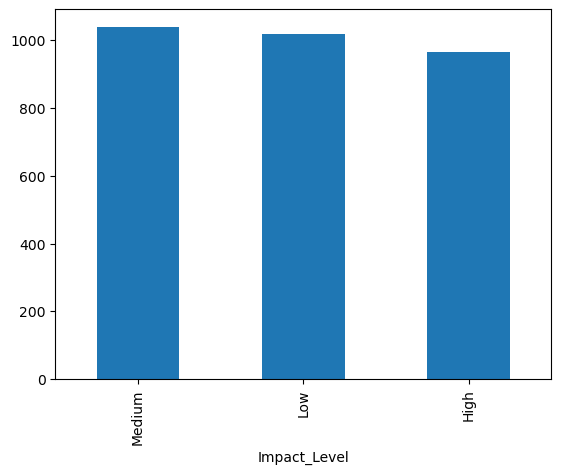

In [ ]:
#Now checking for class imbalance
df["Impact_Level"].value_counts()

df["Impact_Level"].value_counts().plot(kind = 'bar')
plt.show()

From this chart, we can see that Impact_Level classes are well balanced, with each of the categories representing roughtly 1/3 of the dataset. So, no class imbalance corrections (oversampling, class weighting) are needed.

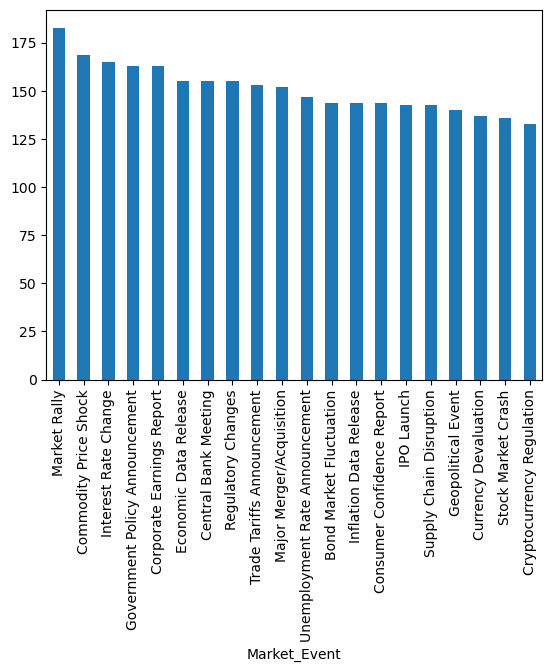

In [ ]:
df["Market_Event"].value_counts().plot(kind = 'bar')
plt.show()

From this, we can observe that Market Rally has the most counts (roughtly 18), and the lowest is cryptocurrency regulation. The rest of the events fall between 150-170

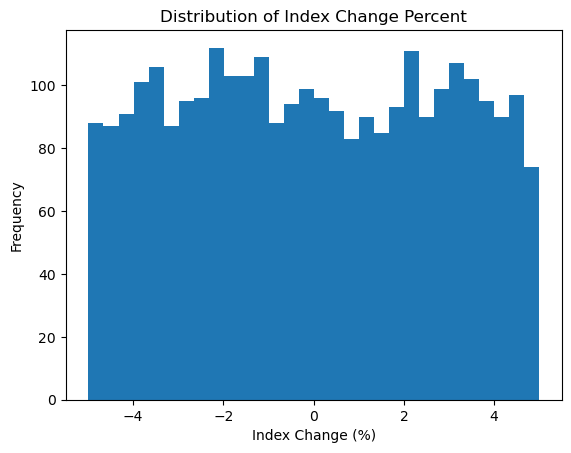

In [ ]:
#Now observing the index change distirbution
plt.hist(df["Index_Change_Percent"], bins = 30)
plt.title("Distribution of Index Change Percent")
plt.xlabel("Index Change (%)")
plt.ylabel("Frequency")
plt.show()


The distirbution of Index_Change_Percent appears approximately uniform with a range between -5-5%, with no strong skew toward positive or negative movements, suggesting a balanced market recations across events and no signficiant outliers.

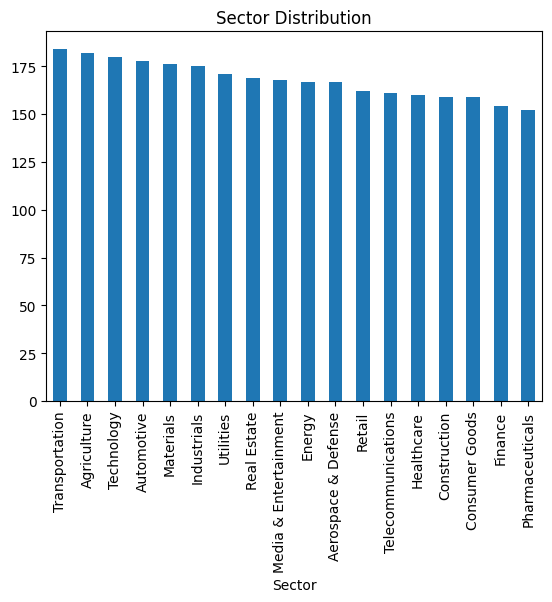

In [ ]:
df["Sector"].value_counts().plot(kind ='bar')
plt.title("Sector Distribution")
plt.show()

The sector disttirbution is relatively balanced across industries, with each sector contributing a similar number of samples. This balanced representation reduces the risk of sector bias in the model and supports generalizability acorss multiple market domains.

This Dataset is a Financial News Events dataset which constins about 3000 recrods of finanical news headlines between January 2025 -August 2025. It includes 12 features capturing textual, categorical, and numerical information related to major global market events. Key variables include news headlines, market event categories, associated stock indices, percentage index changes, trading volume, sentiment labels, sector classifications, impact levels, and related companies. The dataset covers 20 types of market events, 18 global stock indices, 18 business sectors, and news from reputable financial sources such as Reuters and Bloomberg. Approximately 5% of the data contains missing values in select columns, providing a realistic preprocessing scenario..

Overall this dataset is suitable for our finanical news risk tagger as it constains structured event categories, market impact measures, sentiment labels, and connects textual news to quantiative marker reaction. It supports classficiation (through the column Impact_level), sentiment modeling, risk tagging, and event prediction. Since the dataset directly links finanical news to measureable market reactions, it makes it well suited for developing a financial risk tagging pipeline.